# Analyse exploratoire et nettoyage des données
### Scoring de risque de crédit — Séances 3 et 4

Ce notebook part directement du fichier de départ (`data/raw/Loan_default.csv`, jamais modifié) et déroule, étape par étape, deux choses :

1. **L'analyse exploratoire** (S3) : comprendre les données avant d'y toucher, avec des méthodes formelles (pas seulement visuelles) pour détecter les valeurs aberrantes et vérifier les liens statistiques avec la cible.
2. **Le nettoyage** (S4) : appliquer des règles de contrôle, une par une, en expliquant à chaque fois pourquoi on la fait et ce qu'elle donne comme résultat.

Chaque cellule fait **une seule chose**, avec un commentaire qui explique le "pourquoi" et pas seulement le "quoi".

## Étape 0 — Charger les librairies et les données

In [1]:
# pandas : pour manipuler le tableau de données (comme un Excel en Python)
import pandas as pd

# matplotlib et seaborn : pour dessiner des graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# scipy.stats : pour les tests statistiques formels (t-test, chi2, z-score)
from scipy import stats
import numpy as np

sns.set_style("whitegrid")

In [2]:
# On charge le fichier de départ, tel qu'il a été téléchargé (jamais modifié).
df = pd.read_csv("../data/raw/Loan_default.csv")
df.shape

(255347, 18)

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df.dtypes

LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

---
# PARTIE 1 — Analyse exploratoire (S3)

Objectif : comprendre la structure des données avant d'y toucher.
1. Statistiques descriptives
2. Répartition de la cible (`Default`)
3. Distributions (histogrammes)
4. Valeurs extrêmes — visuel puis **confirmation par méthode formelle**
5. Corrélations
6. **Tests statistiques** : chaque variable est-elle vraiment liée à `Default` ?
7. **Représentativité de l'échantillon**

## 1.1 — Séparer les colonnes par type

In [5]:
colonnes_numeriques = [
    "Age", "Income", "LoanAmount", "CreditScore", "MonthsEmployed",
    "NumCreditLines", "InterestRate", "LoanTerm", "DTIRatio"
]

colonnes_categorielles = [
    "Education", "EmploymentType", "MaritalStatus", "HasMortgage",
    "HasDependents", "LoanPurpose", "HasCoSigner"
]

print("Nombre de colonnes numériques :", len(colonnes_numeriques))
print("Nombre de colonnes catégorielles :", len(colonnes_categorielles))

Nombre de colonnes numériques : 9
Nombre de colonnes catégorielles : 7


## 1.2 — Statistiques descriptives

In [6]:
df[colonnes_numeriques].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


**Ce qu'on regarde ici :** est-ce que les valeurs minimum et maximum sont plausibles ?
- `Age` : 18 à 69 ans → plausible
- `CreditScore` : 300 à 849 → conforme à l'échelle FICO
- `DTIRatio` : 0,1 à 0,9 → cohérent, toujours entre 0 et 1

Rien d'impossible à première vue. On confirme ça formellement en 1.4.

## 1.3 — Répartition de la variable cible (Default)

In [7]:
nombre_par_classe = df["Default"].value_counts()
print(nombre_par_classe)
print()
pourcentage_par_classe = df["Default"].value_counts(normalize=True) * 100
print(pourcentage_par_classe.round(1))

Default
0    225694
1     29653
Name: count, dtype: int64

Default
0    88.4
1    11.6
Name: proportion, dtype: float64


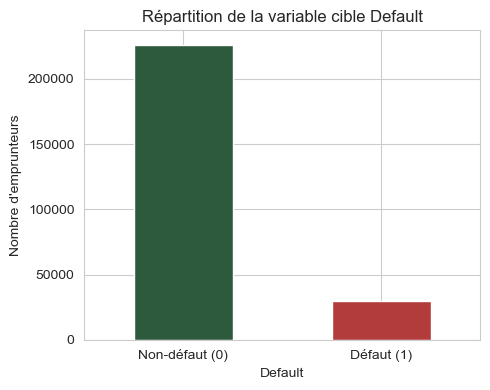

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
nombre_par_classe.sort_index().plot(kind="bar", ax=ax, color=["#2D5A3D", "#B23B3B"])
ax.set_xticklabels(["Non-défaut (0)", "Défaut (1)"], rotation=0)
ax.set_ylabel("Nombre d'emprunteurs")
ax.set_title("Répartition de la variable cible Default")
plt.tight_layout()
plt.show()

**Constat :** ~88 % de non-défauts contre ~12 % de défauts — un **déséquilibre de classes**. Un modèle qui prédirait toujours "pas de défaut" aurait 88 % de bonnes réponses sans être utile : il faudra des métriques adaptées plus tard (AUC-ROC, recall...).

## 1.4 — Distributions des variables numériques

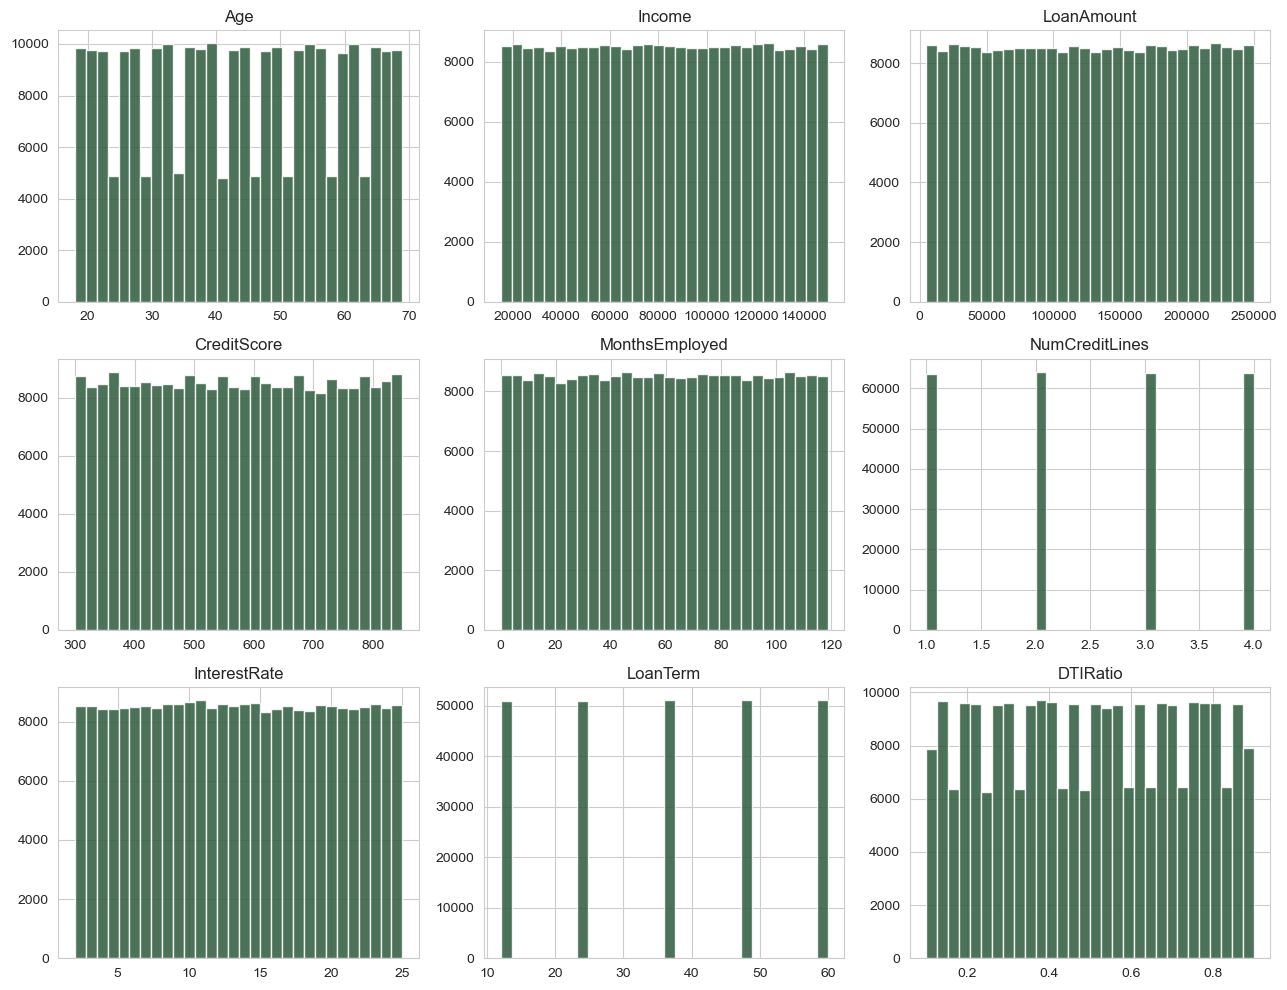

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for case_graphique, nom_colonne in zip(axes.flat, colonnes_numeriques):
    case_graphique.hist(df[nom_colonne], bins=30, color="#2D5A3D", alpha=0.85)
    case_graphique.set_title(nom_colonne)
plt.tight_layout()
plt.show()

**Constat :** distributions presque toutes plates (uniformes), sans pic ni asymétrie — inhabituel pour de vraies données bancaires. On creuse ce point en 1.9.

## 1.5 — Détection visuelle de valeurs extrêmes (boîtes à moustaches)

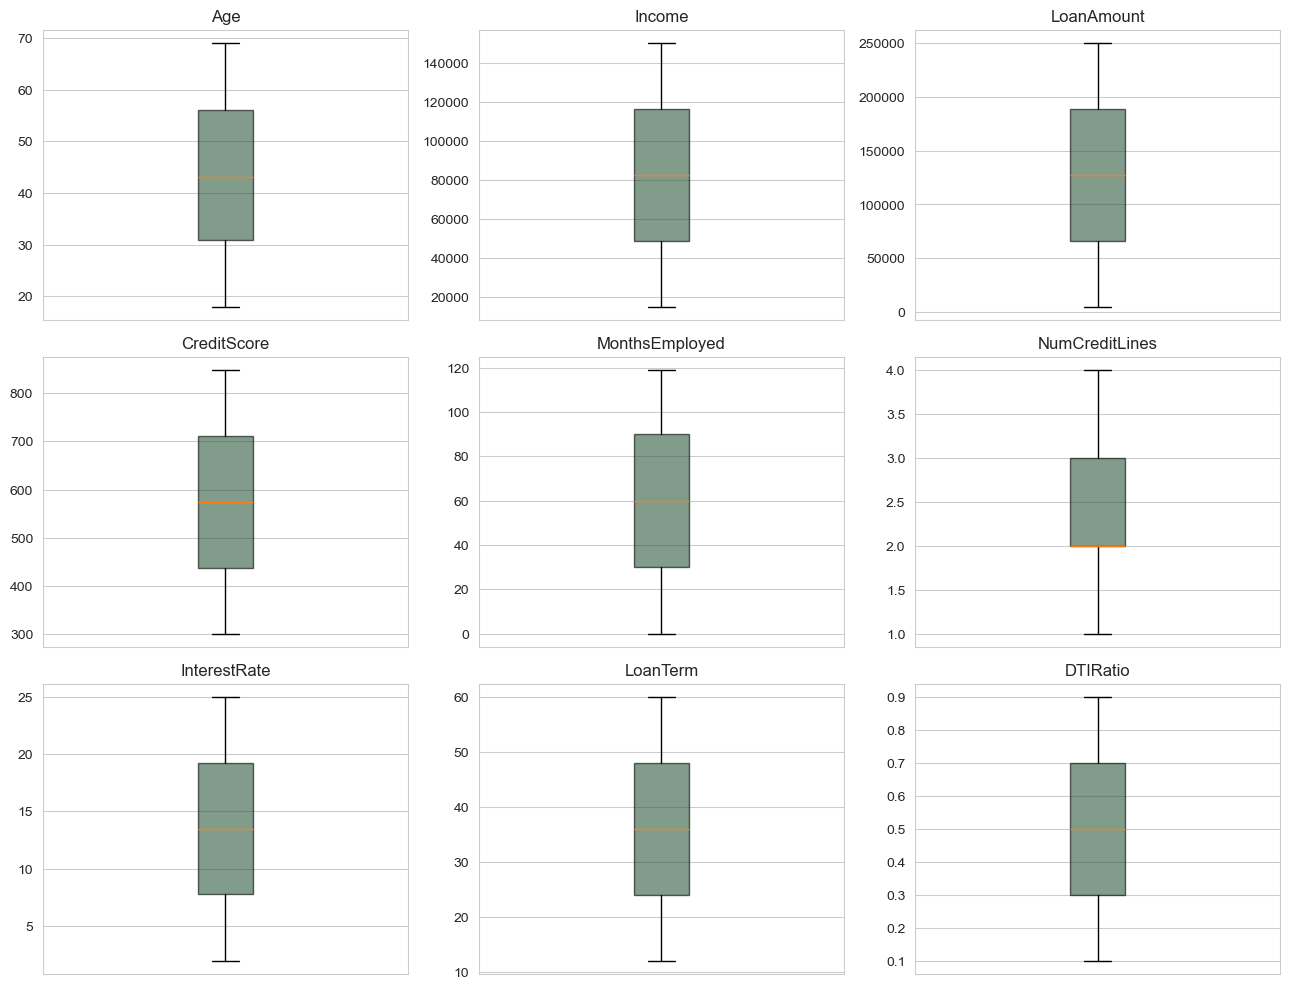

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for case_graphique, nom_colonne in zip(axes.flat, colonnes_numeriques):
    case_graphique.boxplot(df[nom_colonne], patch_artist=True,
                            boxprops=dict(facecolor="#2D5A3D", alpha=0.6))
    case_graphique.set_title(nom_colonne)
    case_graphique.set_xticks([])
plt.tight_layout()
plt.show()

**Constat visuel :** aucun point isolé en dehors des moustaches. On confirme ça avec deux méthodes statistiques formelles ci-dessous — une lecture visuelle seule ne suffit pas comme preuve.

## 1.6 — Confirmer les valeurs aberrantes avec une méthode formelle

- **Méthode IQR** : une valeur est aberrante si elle sort de `[Q1 - 1,5×IQR ; Q3 + 1,5×IQR]`
- **Méthode Z-score** : une valeur est aberrante si `|z| > 3` (à plus de 3 écarts-types de la moyenne)

In [11]:
print("--- Methode IQR ---")
total_iqr = 0
for colonne in colonnes_numeriques:
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    nombre_aberrant = ((df[colonne] < borne_basse) | (df[colonne] > borne_haute)).sum()
    total_iqr += nombre_aberrant
    if nombre_aberrant > 0:
        print(f"{colonne} : {nombre_aberrant} valeurs aberrantes")
print("Total (methode IQR) :", total_iqr)

print()
print("--- Methode Z-score ---")
total_z = 0
for colonne in colonnes_numeriques:
    z_scores = np.abs(stats.zscore(df[colonne]))
    nombre_aberrant = (z_scores > 3).sum()
    total_z += nombre_aberrant
    if nombre_aberrant > 0:
        print(f"{colonne} : {nombre_aberrant} valeurs aberrantes")
print("Total (methode Z-score) :", total_z)

--- Methode IQR ---
Total (methode IQR) : 0

--- Methode Z-score ---
Total (methode Z-score) : 0


**Résultat : 0 valeur aberrante avec les deux méthodes.** Ça confirme formellement l'observation visuelle de 1.5, et justifie qu'aucun traitement de valeurs aberrantes ne sera nécessaire en partie 2 (nettoyage).

## 1.7 — Corrélations entre variables

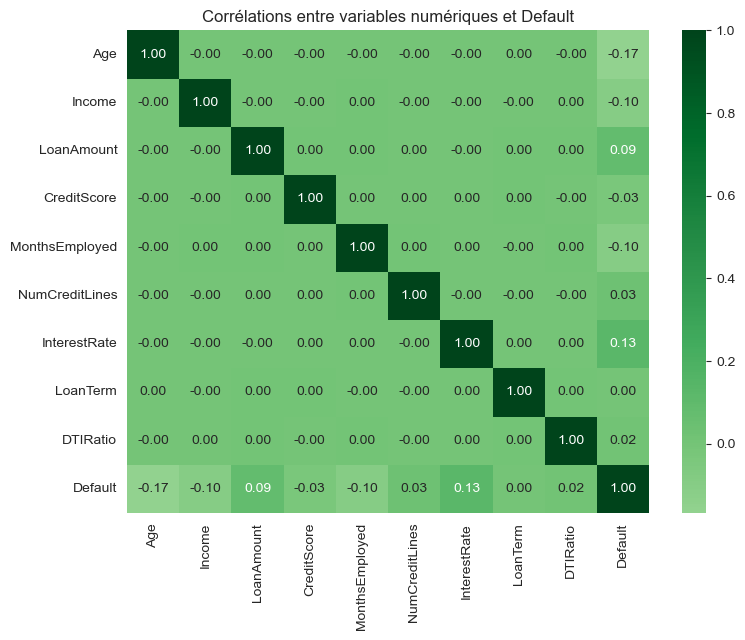

In [12]:
matrice_correlation = df[colonnes_numeriques + ["Default"]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(matrice_correlation, annot=True, fmt=".2f", cmap="Greens", center=0, ax=ax)
ax.set_title("Corrélations entre variables numériques et Default")
plt.tight_layout()
plt.show()

In [13]:
matrice_correlation["Default"].sort_values()

Age              -0.167783
Income           -0.099119
MonthsEmployed   -0.097374
CreditScore      -0.034166
LoanTerm          0.000545
DTIRatio          0.019236
NumCreditLines    0.028330
LoanAmount        0.086659
InterestRate      0.131273
Default           1.000000
Name: Default, dtype: float64

**Constat :** variables numériques quasi indépendantes entre elles (pas de redondance). Liens avec `Default` modérés : `Age` (-0,17), `InterestRate` (+0,13), `Income` (-0,10), `MonthsEmployed` (-0,10). Une corrélation faible ne veut pas dire "pas de lien" — on le vérifie proprement en 1.8.

## 1.8 — Tester si chaque variable est vraiment liée à Default

- **Test t** pour les variables numériques : compare la moyenne chez les emprunteurs en défaut vs les autres.
- **Test du χ²** pour les variables catégorielles : compare la répartition des catégories entre les deux groupes.

Si la p-value est inférieure à 0,05, le lien observé est statistiquement significatif.

In [14]:
print("--- Test t : variables numeriques vs Default ---")
groupe_non_defaut = df[df["Default"] == 0]
groupe_defaut = df[df["Default"] == 1]

for colonne in colonnes_numeriques:
    t_stat, p_value = stats.ttest_ind(groupe_non_defaut[colonne], groupe_defaut[colonne])
    conclusion = "significatif" if p_value < 0.05 else "NON significatif"
    print(f"{colonne:20s} p-value = {p_value:.4f}  ->  {conclusion}")

--- Test t : variables numeriques vs Default ---
Age                  p-value = 0.0000  ->  significatif
Income               p-value = 0.0000  ->  significatif
LoanAmount           p-value = 0.0000  ->  significatif
CreditScore          p-value = 0.0000  ->  significatif
MonthsEmployed       p-value = 0.0000  ->  significatif
NumCreditLines       p-value = 0.0000  ->  significatif
InterestRate         p-value = 0.0000  ->  significatif
LoanTerm             p-value = 0.7831  ->  NON significatif
DTIRatio             p-value = 0.0000  ->  significatif


In [15]:
print("--- Test du chi2 : variables categorielles vs Default ---")
for colonne in colonnes_categorielles:
    tableau_croise = pd.crosstab(df[colonne], df["Default"])
    chi2_stat, p_value, degres_liberte, effectifs_attendus = stats.chi2_contingency(tableau_croise)
    conclusion = "significatif" if p_value < 0.05 else "NON significatif"
    print(f"{colonne:20s} p-value = {p_value:.4f}  ->  {conclusion}")

--- Test du chi2 : variables categorielles vs Default ---
Education            p-value = 0.0000  ->  significatif
EmploymentType       p-value = 0.0000  ->  significatif
MaritalStatus        p-value = 0.0000  ->  significatif
HasMortgage          p-value = 0.0000  ->  significatif
HasDependents        p-value = 0.0000  ->  significatif
LoanPurpose          p-value = 0.0000  ->  significatif
HasCoSigner          p-value = 0.0000  ->  significatif


**Résultat :** 8 des 9 variables numériques sont significativement liées à `Default` (seule `LoanTerm` ne l'est pas), et les 7 variables catégorielles le sont **toutes**. Confirmation importante : même avec des corrélations individuelles faibles, la quasi-totalité des variables porte une vraie information sur le risque de défaut — utile pour la modélisation (S6).

## 1.9 — Vérifier la représentativité de l'échantillon

Recommandation explicite de S3. On regarde si la répartition des catégories ressemble à un vrai portefeuille bancaire (généralement déséquilibré) ou non.

In [16]:
for colonne in colonnes_categorielles:
    repartition = (df[colonne].value_counts(normalize=True) * 100).round(1)
    print(colonne, ":", repartition.to_dict())

Education : {"Bachelor's": 25.2, 'High School': 25.0, "Master's": 24.9, 'PhD': 24.9}
EmploymentType : {'Part-time': 25.1, 'Unemployed': 25.0, 'Self-employed': 24.9, 'Full-time': 24.9}
MaritalStatus : {'Married': 33.4, 'Divorced': 33.3, 'Single': 33.3}
HasMortgage : {'Yes': 50.0, 'No': 50.0}
HasDependents : {'Yes': 50.0, 'No': 50.0}
LoanPurpose : {'Business': 20.1, 'Home': 20.1, 'Education': 20.0, 'Other': 19.9, 'Auto': 19.9}
HasCoSigner : {'Yes': 50.0, 'No': 50.0}


**Résultat :** répartition quasi parfaitement égale entre catégories — ex. 25,2/25,0/24,9/24,9 % pour `Education`, 50,0/50,0 % pour `HasMortgage`. Ce n'est pas plausible pour un échantillon réel de clients bancaires : c'est la signature d'une génération aléatoire uniforme.

**Conclusion sur la représentativité : l'échantillon n'est probablement pas représentatif d'un vrai portefeuille de crédit.** C'est une limite à mentionner explicitement dans le rapport final.

---
# PARTIE 2 — Nettoyage des données (S4)

Objectif : appliquer une série de règles de contrôle, une par une, et documenter le résultat de chacune.

## 2.1 — Règle 1 : les lignes en double

In [17]:
nombre_lignes_dupliquees = df.duplicated().sum()
print("Nombre de lignes entièrement dupliquées :", nombre_lignes_dupliquees)

nombre_id_dupliques = df["LoanID"].duplicated().sum()
print("Nombre de LoanID dupliqués :", nombre_id_dupliques)

Nombre de lignes entièrement dupliquées : 0
Nombre de LoanID dupliqués : 0


**Résultat : 0 dans les deux cas → aucune suppression nécessaire.**

## 2.2 — Règle 2 : les valeurs manquantes

In [18]:
valeurs_manquantes_par_colonne = df.isnull().sum()
print(valeurs_manquantes_par_colonne)
print()
print("Total de valeurs manquantes sur tout le tableau :", df.isnull().sum().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Total de valeurs manquantes sur tout le tableau : 0


**Résultat : 0 valeur manquante → aucune imputation nécessaire.**

## 2.3 — Règle 3 : les valeurs hors des bornes plausibles

In [19]:
bornes_plausibles = {
    "Age":            (18, 100),
    "CreditScore":    (300, 850),
    "InterestRate":   (0, 100),
    "DTIRatio":       (0, 1),
    "Income":         (0, None),
    "LoanAmount":     (0, None),
    "MonthsEmployed": (0, None),
    "NumCreditLines": (0, None),
    "LoanTerm":       (0, None),
}

total_valeurs_hors_bornes = 0
for nom_colonne, (borne_min, borne_max) in bornes_plausibles.items():
    est_hors_bornes = pd.Series(False, index=df.index)
    if borne_min is not None:
        est_hors_bornes = est_hors_bornes | (df[nom_colonne] < borne_min)
    if borne_max is not None:
        est_hors_bornes = est_hors_bornes | (df[nom_colonne] > borne_max)
    nombre_hors_bornes = est_hors_bornes.sum()
    total_valeurs_hors_bornes += nombre_hors_bornes
    if nombre_hors_bornes > 0:
        print(f"{nom_colonne} : {nombre_hors_bornes} valeurs hors bornes")

print()
print("Total toutes variables confondues :", total_valeurs_hors_bornes)


Total toutes variables confondues : 0


**Résultat : 0 valeur hors bornes → aucune correction nécessaire.** (Cohérent avec les méthodes IQR/Z-score de la partie 1.6.)

## 2.4 — Règle 4 : la propreté des catégories textuelles

In [20]:
total_problemes_texte = 0
for nom_colonne in colonnes_categorielles:
    texte_original = df[nom_colonne]
    texte_sans_espaces = df[nom_colonne].str.strip()
    nombre_problemes = (texte_original != texte_sans_espaces).sum()
    total_problemes_texte += nombre_problemes
    if nombre_problemes > 0:
        print(f"{nom_colonne} : {nombre_problemes} valeurs avec espaces parasites")

print("Total :", total_problemes_texte)

for nom_colonne in colonnes_categorielles:
    print(nom_colonne, ":", sorted(df[nom_colonne].unique()))

Total : 0
Education : ["Bachelor's", 'High School', "Master's", 'PhD']
EmploymentType : ['Full-time', 'Part-time', 'Self-employed', 'Unemployed']
MaritalStatus : ['Divorced', 'Married', 'Single']
HasMortgage : ['No', 'Yes']
HasDependents : ['No', 'Yes']
LoanPurpose : ['Auto', 'Business', 'Education', 'Home', 'Other']
HasCoSigner : ['No', 'Yes']


**Résultat : aucun espace parasite, catégories cohérentes → aucune standardisation nécessaire.**

## 2.5 — Règle 5 : la cohérence logique entre deux variables

`Age` et `MonthsEmployed` peuvent être individuellement plausibles mais incohérents ensemble. Hypothèse : personne ne travaille avant 16 ans → `MonthsEmployed` ne doit pas dépasser `(Age - 16) * 12`.

In [21]:
mois_emploi_maximum_plausible = (df["Age"] - 16) * 12
est_incoherent = df["MonthsEmployed"] > mois_emploi_maximum_plausible

nombre_incoherent = est_incoherent.sum()
pourcentage_incoherent = nombre_incoherent / len(df) * 100
print(f"Lignes incohérentes : {nombre_incoherent} ({pourcentage_incoherent:.2f} % du dataset)")

df.loc[est_incoherent, ["Age", "MonthsEmployed"]].head(5)

Lignes incohérentes : 17274 (6.76 % du dataset)


,Age,MonthsEmployed
16,20,49
18,19,119
23,19,73
40,20,117
54,19,59


**Résultat : 6,76 % des lignes (17 274) sont incohérentes.**

**Décision : on ne supprime pas ces lignes**, pour trois raisons : (1) l'hypothèse "16 ans" n'est pas documentée officiellement, (2) supprimer 6,76 % des données perdrait un volume important sans certitude que ce soit une vraie erreur plutôt qu'un artefact du dataset synthétique, (3) `MonthsEmployed` reste individuellement plausible.

**À la place :** on ajoute une colonne indicatrice, pour tester son impact plus tard en modélisation plutôt que de trancher maintenant.

In [22]:
df["AgeEmploymentIncoherent"] = est_incoherent.astype(int)
df["AgeEmploymentIncoherent"].value_counts()

AgeEmploymentIncoherent
0    238073
1     17274
Name: count, dtype: int64

## 2.6 — Règle 6 : les types de données

In [23]:
df.dtypes

LoanID                         str
Age                          int64
Income                       int64
LoanAmount                   int64
CreditScore                  int64
MonthsEmployed               int64
NumCreditLines               int64
InterestRate               float64
LoanTerm                     int64
DTIRatio                   float64
Education                      str
EmploymentType                 str
MaritalStatus                  str
HasMortgage                    str
HasDependents                  str
LoanPurpose                    str
HasCoSigner                    str
Default                      int64
AgeEmploymentIncoherent      int64
dtype: object

**Résultat : types cohérents → aucune conversion nécessaire.** *(L'encodage des catégories est volontairement laissé pour S5.)*

## 2.7 — Bilan et sauvegarde du fichier nettoyé

In [24]:
nombre_lignes_de_depart = 255347
nombre_lignes_conservees = len(df)
print(f"Lignes conservées : {nombre_lignes_conservees} / {nombre_lignes_de_depart}")
print(f"Pourcentage conservé : {nombre_lignes_conservees / nombre_lignes_de_depart * 100:.1f} %")

Lignes conservées : 255347 / 255347
Pourcentage conservé : 100.0 %


In [25]:
df.to_csv("../data/processed/Loan_default_clean.csv", index=False)
print("Fichier sauvegardé avec succès.")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1], "(18 colonnes de départ + 1 indicateur ajouté)")

Fichier sauvegardé avec succès.
Nombre de lignes : 255347
Nombre de colonnes : 19 (18 colonnes de départ + 1 indicateur ajouté)


## Résumé de tout ce qu'on a fait

**Exploration (S3)** — au-delà des statistiques et distributions demandées :
- Valeurs aberrantes confirmées absentes par **2 méthodes formelles** (IQR, Z-score), pas seulement visuellement
- **Tests statistiques** (t-test, χ²) : 15 des 16 variables explicatives significativement liées à `Default`
- **Représentativité vérifiée** : répartition anormalement uniforme des catégories → dataset probablement synthétique, limite documentée

**Nettoyage (S4)** :

| Règle vérifiée | Résultat | Décision |
|---|---|---|
| Lignes / identifiants dupliqués | 0 | Aucune suppression |
| Valeurs manquantes | 0 | Aucune imputation |
| Valeurs hors bornes plausibles | 0 | Aucune correction |
| Espaces parasites dans le texte | 0 | Aucune standardisation |
| Cohérence Age / MonthsEmployed | 17 274 lignes (6,76 %) | Conservées + indicateur ajouté |
| Types de données | Conformes | Aucune conversion |

**100 % des lignes du fichier de départ sont conservées dans le fichier nettoyé.**

Prochaine étape (Séance 5) : encodage des variables catégorielles et feature engineering.